In [1]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [3]:
# ================================
# 2. LOAD DATASET
# ================================
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("Advertising.csv")

# remove unwanted column
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# rename columns (for consistency)
df.columns = ['TV', 'Radio', 'Newspaper', 'Sales']

print("Dataset Preview:")
print(df.head())

Saving Advertising.csv to Advertising.csv
Dataset Preview:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9


In [4]:
# ================================
# 3. CREATE CLASSIFICATION TARGET
# ================================
df['HighSales'] = (df['Sales'] > df['Sales'].mean()).astype(int)

In [5]:
# ================================
# 4. LINEAR REGRESSION (Single Feature)
# ================================
X_lin = df[['TV']]
y_lin = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

print("\n--- Linear Regression ---")
print("MSE:", mean_squared_error(y_test, y_pred_lin))
print("R2 Score:", r2_score(y_test, y_pred_lin))



--- Linear Regression ---
MSE: 10.204654118800956
R2 Score: 0.6766954295627076


In [6]:
# ================================
# 5. MULTIPLE LINEAR REGRESSION
# ================================
X_multi = df[['TV', 'Radio', 'Newspaper']]
y_multi = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

y_pred_multi = multi_model.predict(X_test)

print("\n--- Multiple Linear Regression ---")
print("MSE:", mean_squared_error(y_test, y_pred_multi))
print("R2 Score:", r2_score(y_test, y_pred_multi))


--- Multiple Linear Regression ---
MSE: 3.1740973539761033
R2 Score: 0.899438024100912


In [7]:
# ================================
# 6. LOGISTIC REGRESSION
# ================================
X_log = df[['TV', 'Radio', 'Newspaper']]
y_log = df['HighSales']

X_train, X_test, y_train, y_test = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

# Scaling (important for logistic regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("\n--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))


--- Logistic Regression ---
Accuracy: 0.975
Confusion Matrix:
 [[24  1]
 [ 0 15]]


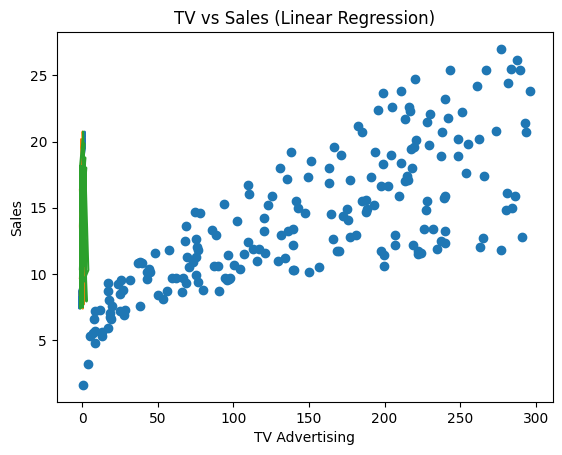

In [8]:
# ================================
# 7. VISUALIZATION (Linear Regression)
# ================================
plt.scatter(df['TV'], df['Sales'])
plt.plot(X_test, y_pred_lin)
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("TV vs Sales (Linear Regression)")
plt.show()